# Augmented Training — Baseline CNN with Generated Data
### Comparative analysis: Baseline vs. Synthetic Augmentation (cVAE, GAN, WGAN-GP, BigGAN, Diffusion)

Implementation details:
- BaselineCNN architecture preserved exactly from `TP2-students.ipynb`
- Unified training pipeline for all experiments to ensure fair comparison
- Stratified evaluation on a common held-out test split
- Balancing of under-represented classes using generated samples


In [48]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import ConcatDataset
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# ── Device Configuration ──────────────────────────────────────────────────
device = torch.device(
    "cuda"  if torch.cuda.is_available()  else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [49]:
# ── Project Path Setup ────────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath(".."))

from src.dataset import (
    ButterflyDataset, AugmentedButterflyDataset,
    get_splits, build_label_map,
    get_train_transform, get_baseline_transform, get_eval_transform, make_dataloader,
)
from src.utils import (
    save_checkpoint, load_checkpoint,
    plot_losses, EarlyStopping,
)
from src.metrics import classification_report_dict

In [50]:
# ── Hyperparameters and Paths ──────────────────────────────────────────────
BASE_DIR  = os.path.abspath("..")
IMG_DIR   = os.path.join(BASE_DIR, "aca-butterflies", "train")
CSV_PATH  = os.path.join(BASE_DIR, "aca-butterflies", "train.csv")

def get_filtered_csv(model_name):
    """Retrieve path to Oracle-filtered metadata, with raw fallback."""
    filtered = os.path.join(BASE_DIR, "data", "generated", model_name, "filtered_generated.csv")
    original = os.path.join(BASE_DIR, "data", "generated", model_name, "generated.csv")
    if os.path.exists(filtered):
        print(f"Using FILTERED dataset for {model_name}")
        return filtered
    print(f"Warning: Filtered dataset not found for {model_name}, falling back to original.")
    return original

CVAE_CSV      = get_filtered_csv("cvae")
GAN_CSV       = get_filtered_csv("gan")
WGAN_GP_CSV   = get_filtered_csv("wgan_gp")
BIGGAN_CSV    = get_filtered_csv("biggan")
DIFFUSION_CSV = get_filtered_csv("diffusion")
AUG_DIR       = os.path.join(BASE_DIR, "data", "augmented")
os.makedirs(AUG_DIR, exist_ok=True)

IMAGE_SIZE   = 64
BATCH_SIZE   = 64
LR           = 0.001
NUM_EPOCHS   = 100
ES_PATIENCE  = 15
LR_PATIENCE  = 7
LR_FACTOR    = 0.5
LR_MIN       = 1e-5

Using FILTERED dataset for cvae
Using FILTERED dataset for gan
Using FILTERED dataset for wgan_gp
Using FILTERED dataset for biggan
Using FILTERED dataset for diffusion


In [51]:
# ── Dataset Initialization ────────────────────────────────────────────────
label_to_idx, idx_to_label = build_label_map(CSV_PATH)
num_classes = len(label_to_idx)
print(f"Number of classes: {num_classes}")

train_df, val_df, test_df = get_splits(CSV_PATH, train_ratio=0.70, val_ratio=0.15, seed=42)
print(f"Original — Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

Number of classes: 75
Original — Train: 3,606  Val: 745  Test: 848


## Model Architecture

### BaselineCNN
Preservation of the competition baseline architecture for empirical comparison.


In [52]:
class BaselineCNN(nn.Module):
    """Reference CNN architecture from TP2-students.ipynb."""

    def __init__(self, num_classes=75):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)



In [53]:
def train_classifier(model, train_loader, val_loader,
                     num_epochs=NUM_EPOCHS, lr=LR,
                     es_patience=ES_PATIENCE, device=device,
                     save_path=None, run_name=""):
    """Standardized training loop for classifier experiments."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=LR_PATIENCE,
        factor=LR_FACTOR, min_lr=LR_MIN,
    )
    es = EarlyStopping(patience=es_patience, mode="max")

    model = model.to(device)
    train_losses, val_losses, val_accs = [], [], []
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # ── Train ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train = running_loss / len(train_loader)
        train_losses.append(avg_train)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        avg_val  = val_loss / len(val_loader)
        acc      = correct / total
        val_losses.append(avg_val)
        val_accs.append(acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{run_name}] Epoch: {epoch+1:3d}  "
              f"Train Loss: {avg_train:.4f}  Val Loss: {avg_val:.4f}  Val Acc: {acc:.4f}  LR: {current_lr:.2e}")

        if acc > best_val_acc and save_path:
            best_val_acc = acc
            save_checkpoint(model, save_path, epoch=epoch+1, val_acc=acc)

        scheduler.step(acc)

        if es(acc):
            print(f"Early stopping at epoch {epoch+1}")
            break

    return model.to("cpu"), train_losses, val_losses, val_accs



In [54]:
def evaluate_classifier(model, test_loader, label_to_idx, idx_to_label, device=device):
    """Compute comprehensive metrics on held-out test split."""
    model = model.to(device)
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_true.extend(labels.tolist())
    return classification_report_dict(all_true, all_preds, idx_to_label)



In [55]:
# ── Augmentation Utilities ────────────────────────────────────────────────
def create_balanced_augmented_df(orig_df, gen_df, target_per_class=None):
    """Construct a class-balanced DataFrame using synthetic samples."""
    if target_per_class is None:
        target_per_class = orig_df["label"].value_counts().max()
    
    balanced_rows = [orig_df]
    
    for label, group in orig_df.groupby("label"):
        num_orig = len(group)
        num_needed = target_per_class - num_orig
        
        if num_needed > 0:
            gen_candidates = gen_df[gen_df["label"] == label]
            if len(gen_candidates) > 0:
                num_to_add = min(num_needed, len(gen_candidates))
                balanced_rows.append(gen_candidates.sample(n=num_to_add, random_state=42))
                
    return pd.concat(balanced_rows, ignore_index=True)

# ── Global Test Loader ────────────────────────────────────────────────────
test_set    = ButterflyDataset(test_df, IMG_DIR, label_to_idx,
                                transform=get_eval_transform(IMAGE_SIZE))
test_loader = make_dataloader(test_set, BATCH_SIZE, shuffle=False)

Test samples: 848


## Run 1 — Baseline (Reference)

Evaluation of the model trained exclusively on the original dataset.


In [56]:
baseline_train_set = ButterflyDataset(train_df, IMG_DIR, label_to_idx,
                                       transform=get_train_transform(IMAGE_SIZE))
baseline_val_set   = ButterflyDataset(val_df,   IMG_DIR, label_to_idx,
                                       transform=get_eval_transform(IMAGE_SIZE))

baseline_train_loader = make_dataloader(baseline_train_set, BATCH_SIZE, shuffle=True)
baseline_val_loader   = make_dataloader(baseline_val_set,   BATCH_SIZE, shuffle=False)

baseline_model = BaselineCNN(num_classes=num_classes)

baseline_model, bl_train_l, bl_val_l, bl_val_acc = train_classifier(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    run_name="BASELINE",
    save_path=os.path.join(BASE_DIR, "saved_models", "baseline.pth"),
)

Baseline — Train: 3,606  Val: 745


[BASELINE] Epoch:   1  Train Loss: 4.2480  Val Loss: 4.0438  Val Acc: 0.0322  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   2  Train Loss: 4.0074  Val Loss: 3.7600  Val Acc: 0.0671  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   3  Train Loss: 3.8052  Val Loss: 3.7793  Val Acc: 0.0752  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   4  Train Loss: 3.5884  Val Loss: 3.3590  Val Acc: 0.0872  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   5  Train Loss: 3.4702  Val Loss: 3.3378  Val Acc: 0.0993  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   6  Train Loss: 3.3255  Val Loss: 3.2517  Val Acc: 0.1060  LR: 1.00e-03
[checkpoint] saved → c:\Users

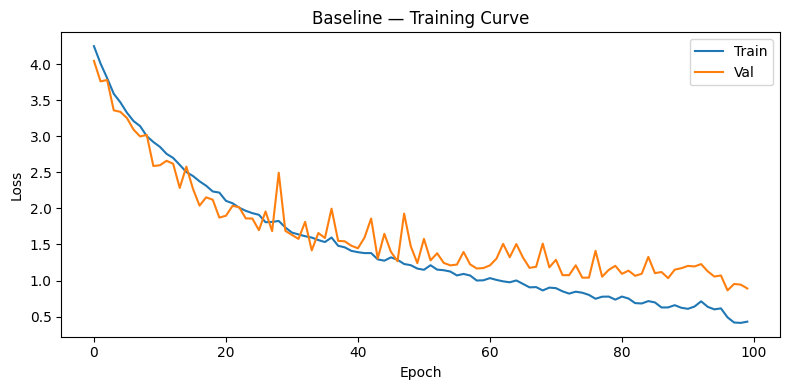

In [57]:
load_checkpoint(os.path.join(BASE_DIR, "saved_models", "baseline.pth"), baseline_model)
baseline_metrics = evaluate_classifier(baseline_model, test_loader, label_to_idx, idx_to_label)
print(f"Baseline Accuracy: {baseline_metrics['accuracy']:.4f}")

## Run 2 — +cVAE Augmentation


In [58]:
cvae_gen_df = pd.read_csv(CVAE_CSV)
combined_cvae_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), cvae_gen_df)
combined_cvae_df.to_csv(os.path.join(AUG_DIR, "cvae_augmented.csv"), index=False)

cvae_aug_train = AugmentedButterflyDataset(combined_cvae_df, label_to_idx,
                                            transform=get_train_transform(IMAGE_SIZE))
cvae_train_loader = make_dataloader(cvae_aug_train, BATCH_SIZE, shuffle=True)

cvae_model = BaselineCNN(num_classes=num_classes)
cvae_model, cv_train_l, cv_val_l, cv_val_acc = train_classifier(
    cvae_model, cvae_train_loader, baseline_val_loader,
    run_name="+cVAE", save_path=os.path.join(BASE_DIR, "saved_models", "baseline_cvae.pth"),
)

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
Baseline  |  Accuracy: 0.7594  Macro F1: 0.7578


## Run 3 — +GAN Augmentation


In [59]:
gan_gen_df = pd.read_csv(GAN_CSV)
combined_gan_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), gan_gen_df)
combined_gan_df.to_csv(os.path.join(AUG_DIR, "gan_augmented.csv"), index=False)

gan_aug_train = AugmentedButterflyDataset(combined_gan_df, label_to_idx,
                                           transform=get_train_transform(IMAGE_SIZE))
gan_train_loader = make_dataloader(gan_aug_train, BATCH_SIZE, shuffle=True)

gan_model = BaselineCNN(num_classes=num_classes)
gan_model, gn_train_l, gn_val_l, gn_val_acc = train_classifier(
    gan_model, gan_train_loader, baseline_val_loader,
    run_name="+GAN", save_path=os.path.join(BASE_DIR, "saved_models", "baseline_gan.pth"),
)

cVAE generated samples: 7
Combined balanced (original + cVAE): 3,613
Augmented train batches: 57


## Run 4 — +WGAN-GP Augmentation


[+cVAE] Epoch:   1  Train Loss: 4.2319  Val Loss: 4.1828  Val Acc: 0.0295  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   2  Train Loss: 4.0237  Val Loss: 3.8289  Val Acc: 0.0497  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   3  Train Loss: 3.8942  Val Loss: 3.8675  Val Acc: 0.0456  LR: 1.00e-03
[+cVAE] Epoch:   4  Train Loss: 3.7744  Val Loss: 3.7341  Val Acc: 0.0523  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   5  Train Loss: 3.5698  Val Loss: 3.7388  Val Acc: 0.0886  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   6  Train Loss: 3.4510  Val Loss: 3.4192  Val Acc: 0.1007  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   7  Tr

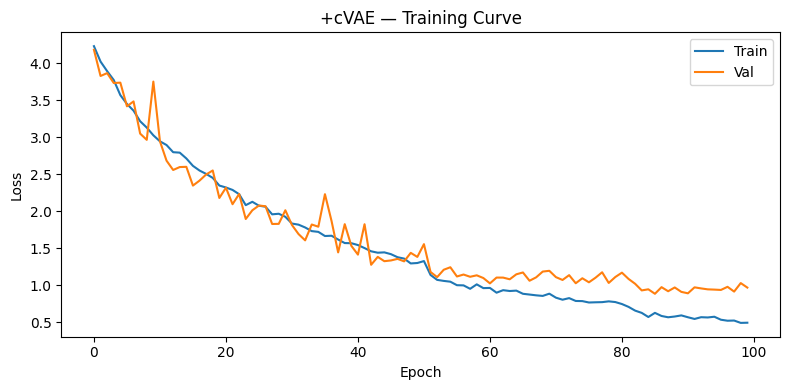

In [60]:
wgan_gp_gen_df = pd.read_csv(WGAN_GP_CSV)
combined_wgan_gp_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), wgan_gp_gen_df)
combined_wgan_gp_df.to_csv(os.path.join(AUG_DIR, "wgan_gp_augmented.csv"), index=False)

wgan_gp_aug_train = AugmentedButterflyDataset(combined_wgan_gp_df, label_to_idx,
                                               transform=get_train_transform(IMAGE_SIZE))
wgan_gp_train_loader = make_dataloader(wgan_gp_aug_train, BATCH_SIZE, shuffle=True)

wgan_gp_model = BaselineCNN(num_classes=num_classes)
wgan_gp_model, wg_train_l, wg_val_l, wg_val_acc = train_classifier(
    wgan_gp_model, wgan_gp_train_loader, baseline_val_loader,
    run_name="+WGAN-GP", save_path=os.path.join(BASE_DIR, "saved_models", "baseline_wgan_gp.pth"),
)

## Run 5 — +BigGAN Augmentation


In [61]:
biggan_gen_df = pd.read_csv(BIGGAN_CSV)
combined_biggan_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), biggan_gen_df)
combined_biggan_df.to_csv(os.path.join(AUG_DIR, "biggan_augmented.csv"), index=False)

biggan_aug_train = AugmentedButterflyDataset(combined_biggan_df, label_to_idx,
                                              transform=get_train_transform(IMAGE_SIZE))
biggan_train_loader = make_dataloader(biggan_aug_train, BATCH_SIZE, shuffle=True)

biggan_model = BaselineCNN(num_classes=num_classes)
biggan_model, bg_train_l, bg_val_l, bg_val_acc = train_classifier(
    biggan_model, biggan_train_loader, baseline_val_loader,
    run_name="+BigGAN", save_path=os.path.join(BASE_DIR, "saved_models", "baseline_biggan.pth"),
)

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
+cVAE     |  Accuracy: 0.7535  Macro F1: 0.7518


## Run 6 — +Diffusion Augmentation


In [62]:
diff_gen_df = pd.read_csv(DIFFUSION_CSV)
combined_diff_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), diff_gen_df)
combined_diff_df.to_csv(os.path.join(AUG_DIR, "diffusion_augmented.csv"), index=False)

diff_aug_train = AugmentedButterflyDataset(combined_diff_df, label_to_idx,
                                            transform=get_train_transform(IMAGE_SIZE))
diff_train_loader = make_dataloader(diff_aug_train, BATCH_SIZE, shuffle=True)

diff_model = BaselineCNN(num_classes=num_classes)
diff_model, df_train_l, df_val_l, df_val_acc = train_classifier(
    diff_model, diff_train_loader, baseline_val_loader,
    run_name="+Diffusion", save_path=os.path.join(BASE_DIR, "saved_models", "baseline_diffusion.pth"),
)

GAN generated samples: 94
Combined balanced (original + GAN): 3,700
Augmented train batches: 58


## Results Summary

Comprehensive performance comparison across all augmentation strategies.


[+GAN] Epoch:   1  Train Loss: 4.2566  Val Loss: 4.1209  Val Acc: 0.0376  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   2  Train Loss: 4.0629  Val Loss: 3.9497  Val Acc: 0.0510  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   3  Train Loss: 3.9121  Val Loss: 3.7225  Val Acc: 0.0698  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   4  Train Loss: 3.7062  Val Loss: 3.5162  Val Acc: 0.0966  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   5  Train Loss: 3.5704  Val Loss: 3.3493  Val Acc: 0.1329  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   6  Train Loss: 3.4053  Val Loss: 3.1543  Val Acc: 0.1409  LR: 1.00e-03
[checkpoint] saved → c:\Users\ric

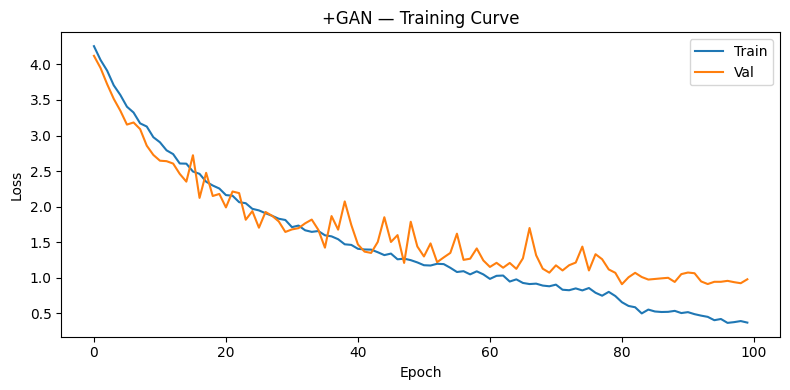

In [63]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for acc_curve, label in zip([bl_val_acc, cv_val_acc, gn_val_acc, wg_val_acc, bg_val_acc, df_val_acc],
                            ["Baseline", "+cVAE", "+GAN", "+WGAN-GP", "+BigGAN", "+Diffusion"]):
    plt.plot(acc_curve, label=label)
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.title("Validation Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# Final metric evaluation for all runs
results = {}
for name, path in [("Baseline", "baseline.pth"), ("+cVAE", "baseline_cvae.pth"), 
                 ("+GAN", "baseline_gan.pth"), ("+WGAN-GP", "baseline_wgan_gp.pth"),
                 ("+BigGAN", "baseline_biggan.pth"), ("+Diffusion", "baseline_diffusion.pth")]:
    load_checkpoint(os.path.join(BASE_DIR, "saved_models", path), baseline_model)
    results[name] = evaluate_classifier(baseline_model, test_loader, label_to_idx, idx_to_label)

print(f"{'Model':<12} {'Top-1 Acc':>10} {'Macro F1':>10}")
print("-" * 34)
for name, m in results.items():
    print(f"{name:<12} {m['accuracy']:>10.4f} {m['macro_f1']:>10.4f}")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
+GAN      |  Accuracy: 0.7677  Macro F1: 0.7684
